In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


from sklearn.model_selection import train_test_split

Feature (X):
Study Hours per day

Target (Y):
Exam Marks

Goal: Best line find 

𝑦
=
𝑤
𝑥
+
𝑏
y=wx+b

where

w = slope (marks increase per hour)

b = bias (base marks)

In [32]:
df=pd.read_csv('student_marks.csv')
df.head(5)

,Unnamed: 0.1,Unnamed: 0,Study_Hours,Marks
0,0,0,3.745401,16.591606
1,1,1,9.507143,30.850740
2,2,2,7.319939,27.720214
3,3,3,5.986585,24.180926
4,4,4,1.560186,10.800140


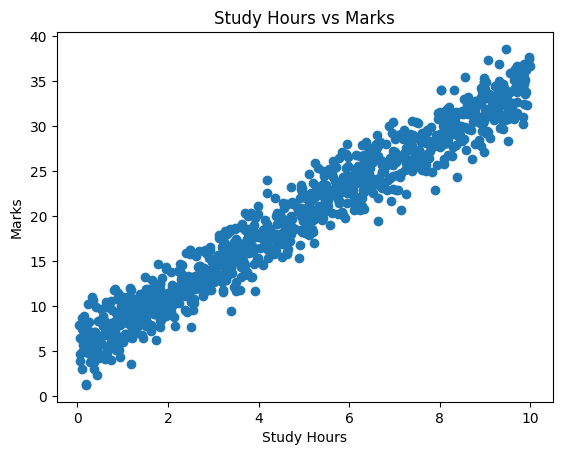

In [33]:
plt.scatter(df["Study_Hours"],df["Marks"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

In [34]:
X = df[["Study_Hours"]]   # feature
y = df["Marks"]           # target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
print("Training Data Shape:", X_train.shape, y_train.shape)
print("Testing Data Shape:", X_test.shape, y_test.shape)

Training Data Shape: (800, 1) (800,)
Testing Data Shape: (200, 1) (200,)


In [36]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [37]:
print("Slope (Weight):", model.coef_[0])
print("Intercept (Bias):", model.intercept_)

Slope (Weight): 2.9648191571183204
Intercept (Bias): 5.379714585496467


In [38]:
predicted_marks = model.predict([[6]])

print("Predicted Marks:", predicted_marks[0])

Predicted Marks: 23.168629528206388


c:\Users\Moazzam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


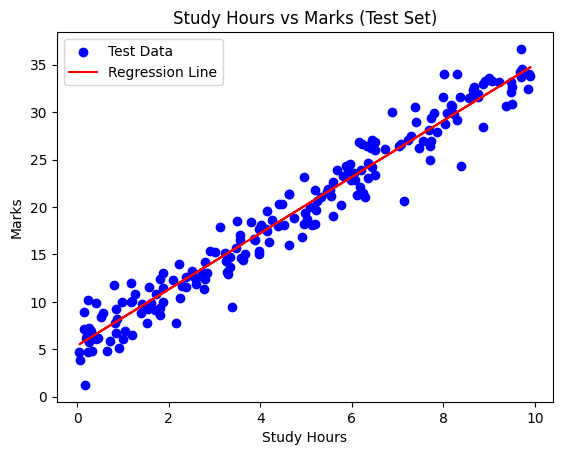

In [41]:
plt.scatter(X_test, y_test, color='blue', label='Test Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks (Test Set)')
plt.legend()
plt.show()

In [40]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score on Test Set:", r2)

R² Score on Test Set: 0.9558514680538264


In [42]:
y_train_pred = model.predict(X_train)
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print("Training R²:", r2_train)
print("Testing R²:", r2_test)

Training R²: 0.9493182545733432
Testing R²: 0.9558514680538264


In [43]:
# R² already calculated
print("Training R²:", r2_train)
print("Testing R²:", r2_test)

Training R²: 0.9493182545733432
Testing R²: 0.9558514680538264


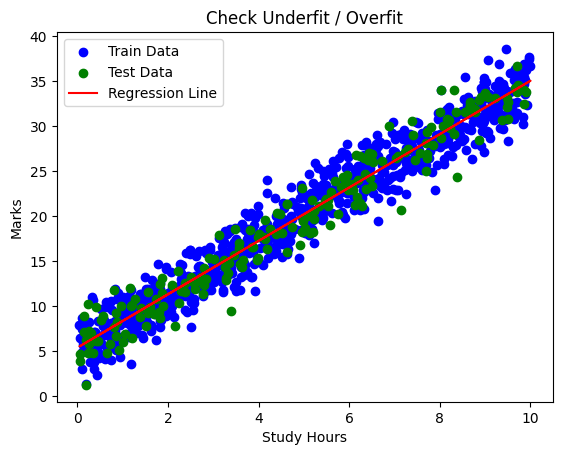

In [44]:
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(X_train, y_train_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend()
plt.title('Check Underfit / Overfit')
plt.show()